# Green Wall Scoring + Budget Optimizer

Scores every building (1–10) for green wall installation potential, then provides a budget optimizer for city planners.

## Scoring formula

```
eligible_wall_area = building_perimeter × building_height × coverage_ratio

raw = heat_priority_nearby       # how hot is this location?
    × eligible_wall_area          # how much wall surface is available?
    × sun_score                   # how much sun does the building get?
    × exp(-dist_to_hot_cell/300)  # distance decay to nearest hotspot (300 m influence radius)
    × predicted_cooling           # model-predicted LST reduction

green_wall_score = 1–10 scale of log1p(raw), min-max normalised
```

The raw score is **log-transformed before normalising** — a few buildings sitting directly on
hotspots produce extreme raw values, and a plain min-max would compress all other buildings to ~1.
`log1p` spreads the distribution so the 1–10 scale is informative across the whole city.

## Sun score
Each wall segment's outward-facing bearing is computed from the building polygon.
South-facing walls (bearing 180°) get maximum sun in Israel (Northern Hemisphere).
A shade penalty is applied if a taller building exists within 25 m to the south.

## Budget optimizer
Buildings are ranked by `score / cost`. A greedy selection picks buildings in rank order
until the budget is exhausted — standard knapsack approximation.
Assumed cost: **₪1,500 per m² of green wall**.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import Point
from pathlib import Path

DATA = Path('../Layers')
OUT  = Path('../outputs')

COVERAGE_RATIO  = 0.4    # fraction of wall area covered by vegetation
COST_PER_M2     = 1500   # ILS per m²
SHADE_RADIUS    = 25     # metres — check for taller buildings within this distance to south
DECAY_DISTANCE  = 300    # metres — distance decay constant (urban cooling influence radius)
print('Setup OK')

Setup OK


## 1 — Load Data

In [2]:
buildings = gpd.read_file(DATA / 'tel_aviv_buildings_only_ITM.geojson')   # EPSG:2039
grid      = gpd.read_file(OUT  / 'tel_aviv_grid_features.gpkg')           # EPSG:2039 (filtered)

# Ensure same CRS
grid = grid.to_crs(2039)

print(f'Buildings : {len(buildings):,}')
print(f'Grid cells: {len(grid):,}  (heat_priority range: {grid["heat_priority"].min():.3f}–{grid["heat_priority"].max():.3f})')

Buildings : 25,818
Grid cells: 5,080  (heat_priority range: 0.000–1.000)


## 2 — Basic Building Geometry Features

In [3]:
buildings = buildings.copy()
buildings['perimeter']          = buildings.geometry.length
buildings['footprint_area']     = buildings.geometry.area
buildings['eligible_wall_area'] = buildings['perimeter'] * buildings['height'] * COVERAGE_RATIO
buildings['cost_ils']           = buildings['eligible_wall_area'] * COST_PER_M2
buildings['centroid']           = buildings.geometry.centroid

print(f'Median perimeter     : {buildings["perimeter"].median():.0f} m')
print(f'Median eligible area : {buildings["eligible_wall_area"].median():.0f} m²')
print(f'Median cost          : ₪{buildings["cost_ils"].median():,.0f}')

Median perimeter     : 69 m
Median eligible area : 281 m²
Median cost          : ₪421,341


## 3 — Sun Score

For each building polygon edge (wall segment), compute the **outward-facing bearing** using the right-hand perpendicular rule for CCW polygons.
Then aggregate to a building-level sun score weighted by wall length.

```
sun_score_per_wall = (cos(bearing - 180°) + 1) / 2     # 1.0 = south, 0.0 = north
sun_score_building = Σ(sun_score × wall_length) / Σ(wall_length)
```

In [4]:
def building_sun_score(geom):
    """Weighted-average sun score across all wall segments of a building polygon."""
    # Some buildings are MultiPolygons — use the largest part
    if geom.geom_type == 'MultiPolygon':
        geom = max(geom.geoms, key=lambda g: g.area)
    coords = list(geom.exterior.coords)
    total_weighted, total_length = 0.0, 0.0
    for i in range(len(coords) - 1):
        x1, y1 = coords[i]
        x2, y2 = coords[i + 1]
        dx, dy = x2 - x1, y2 - y1
        length = np.hypot(dx, dy)
        if length < 0.01:
            continue
        # Outward normal bearing (CCW polygon, right-hand perpendicular)
        bearing = np.degrees(np.arctan2(dy, -dx)) % 360
        # South-facing score: max at bearing=180, zero at bearing=0/360
        score = (np.cos(np.radians(bearing - 180)) + 1) / 2
        total_weighted += score * length
        total_length   += length
    return total_weighted / total_length if total_length > 0 else 0.5

print('Computing sun scores...')
buildings['sun_score_raw'] = buildings.geometry.apply(building_sun_score)
print(f'Sun score range: {buildings["sun_score_raw"].min():.3f}–{buildings["sun_score_raw"].max():.3f}  mean: {buildings["sun_score_raw"].mean():.3f}')

Computing sun scores...


Sun score range: 0.500–0.500  mean: 0.500


## 4 — Shade Penalty

If a taller building exists within `SHADE_RADIUS` metres to the **south** of a building, its sun score is penalised.
The penalty scales with how much taller the obstructing building is.

In [5]:
print('Computing shade penalties (spatial index)...')

centroids = buildings['centroid']
bld_idx   = buildings.sindex   # spatial index on building polygons

shade_penalty = np.zeros(len(buildings))

for i, row in buildings.iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    # Southern search box: centre shifted 0–SHADE_RADIUS metres to the south
    south_box = (cx - SHADE_RADIUS, cy - SHADE_RADIUS,
                 cx + SHADE_RADIUS, cy)
    candidates = list(bld_idx.intersection(south_box))
    for j in candidates:
        if j == i:
            continue
        neighbor = buildings.iloc[j]
        # Neighbor must be to the south AND taller
        if (neighbor['centroid'].y < cy and
            neighbor['height']    > row['height']):
            # Penalty proportional to height excess, capped at 0.5
            excess = min((neighbor['height'] - row['height']) / row['height'], 1.0)
            shade_penalty[i] = max(shade_penalty[i], excess * 0.5)

buildings['shade_penalty'] = shade_penalty
buildings['sun_score']     = (buildings['sun_score_raw'] * (1 - buildings['shade_penalty'])).clip(0, 1)

shaded = (buildings['shade_penalty'] > 0).sum()
print(f'Buildings with shade penalty: {shaded:,} ({shaded/len(buildings):.1%})')
print(f'Sun score after penalty: mean={buildings["sun_score"].mean():.3f}')

Computing shade penalties (spatial index)...


Buildings with shade penalty: 14,066 (54.5%)
Sun score after penalty: mean=0.446


## 5 — Join Grid Heat Features to Buildings

In [6]:
# Join each building to the grid cell it intersects (or nearest if it falls between cells)
grid_cols = grid[['heat_priority', 'predicted_cooling', 'geometry']]

bld_grid = gpd.sjoin(
    buildings[['id', 'height', 'eligible_wall_area', 'cost_ils',
               'sun_score', 'centroid', 'geometry']],
    grid_cols,
    how='left',
    predicate='intersects'
)

# Buildings spanning multiple cells → take the mean
bld_agg = (
    bld_grid.groupby('id')[['heat_priority', 'predicted_cooling']]
    .mean()
    .reset_index()
)
buildings = buildings.merge(bld_agg, on='id', how='left')
buildings[['heat_priority', 'predicted_cooling']] = buildings[
    ['heat_priority', 'predicted_cooling']
].fillna(0)

print(f'Buildings with heat data: {(buildings["heat_priority"] > 0).sum():,}')

Buildings with heat data: 25,630


## 6 — Distance to Nearest Hotspot

In [7]:
hotspots = grid[grid['is_hotspot'] == 1][['geometry']].copy()
bld_centroids = buildings.copy()
bld_centroids['geometry'] = buildings['centroid']

dist_df = gpd.sjoin_nearest(
    bld_centroids[['id', 'geometry']],
    hotspots,
    how='left',
    distance_col='dist_to_hotspot'
).drop_duplicates('id').set_index('id')['dist_to_hotspot']

buildings['dist_to_hotspot'] = buildings['id'].map(dist_df).fillna(dist_df.max())
print(f'Median dist to hotspot: {buildings["dist_to_hotspot"].median():.0f} m')

Median dist to hotspot: 12 m


## 7 — Green Wall Score (1–10)

In [8]:
decay = np.exp(-buildings['dist_to_hotspot'] / DECAY_DISTANCE)

raw_score = (
    buildings['heat_priority']
    * buildings['eligible_wall_area']
    * buildings['sun_score']
    * decay
    * (buildings['predicted_cooling'] + 0.01)   # +0.01 avoids zero for buildings with no modelled cooling
)

# Log-transform before normalising: a handful of buildings on hotspots produce extreme
# raw values; a plain min-max would crush everyone else to ~1. log1p spreads the scale.
raw_log = np.log1p(raw_score)
buildings['green_wall_score'] = 1 + 9 * (raw_log - raw_log.min()) / (raw_log.max() - raw_log.min())
buildings['score_per_cost']   = buildings['green_wall_score'] / buildings['cost_ils'].clip(lower=1)

print(buildings['green_wall_score'].describe().round(2))
print(f"\nTop 5 buildings:")
top5 = buildings.nlargest(5, 'green_wall_score')[['id','height','eligible_wall_area','sun_score','heat_priority','green_wall_score','cost_ils']]
print(top5.round(2).to_string())

count    25818.00
mean         3.73
std          1.34
min          1.00
25%          2.88
50%          3.81
75%          4.56
max         10.00
Name: green_wall_score, dtype: float64

Top 5 buildings:
                         id  height  eligible_wall_area  sun_score  heat_priority  green_wall_score     cost_ils
25518  000000000000000281c7    67.0            27782.38        0.5           0.26             10.00  41673565.49
25770  0000000000000002f2a9   139.0            37324.65        0.5           0.27              9.93  55986973.22
25457  0000000000000002a160    60.0            18819.67        0.5           0.32              9.85  28229506.37
24474  0000000000000002b2e9    28.0            11175.82        0.5           0.47              9.46  16763730.54
25729  00000000000000008e6e   112.0            16730.87        0.5           0.43              9.36  25096299.13


## 8 — Budget Optimizer

In [9]:
def budget_optimizer(buildings_df, budget_ils, cost_col='cost_ils',
                     score_col='green_wall_score'):
    """Greedy knapsack: rank by score/cost, pick until budget exhausted."""
    ranked = buildings_df.sort_values('score_per_cost', ascending=False).copy()
    selected, spent, total_score = [], 0.0, 0.0
    for _, row in ranked.iterrows():
        if spent + row[cost_col] <= budget_ils:
            selected.append(row['id'])
            spent       += row[cost_col]
            total_score += row[score_col]
    return selected, spent, total_score

budgets = [5_000_000, 20_000_000, 50_000_000]   # 5M / 20M / 50M ILS

print(f"{'Budget':>12}  {'Buildings':>10}  {'Spent':>12}  {'Total Score':>12}")
print('-' * 52)
results = {}
for b in budgets:
    ids, spent, score = budget_optimizer(buildings, b)
    results[b] = ids
    print(f"₪{b:>11,.0f}  {len(ids):>10,}  ₪{spent:>11,.0f}  {score:>12.1f}")

      Budget   Buildings         Spent   Total Score
----------------------------------------------------


₪  5,000,000          97  ₪  4,989,450         234.7


₪ 20,000,000         270  ₪ 19,975,966         727.6


₪ 50,000,000         548  ₪ 49,989,054        1548.7


## 9 — Visualise

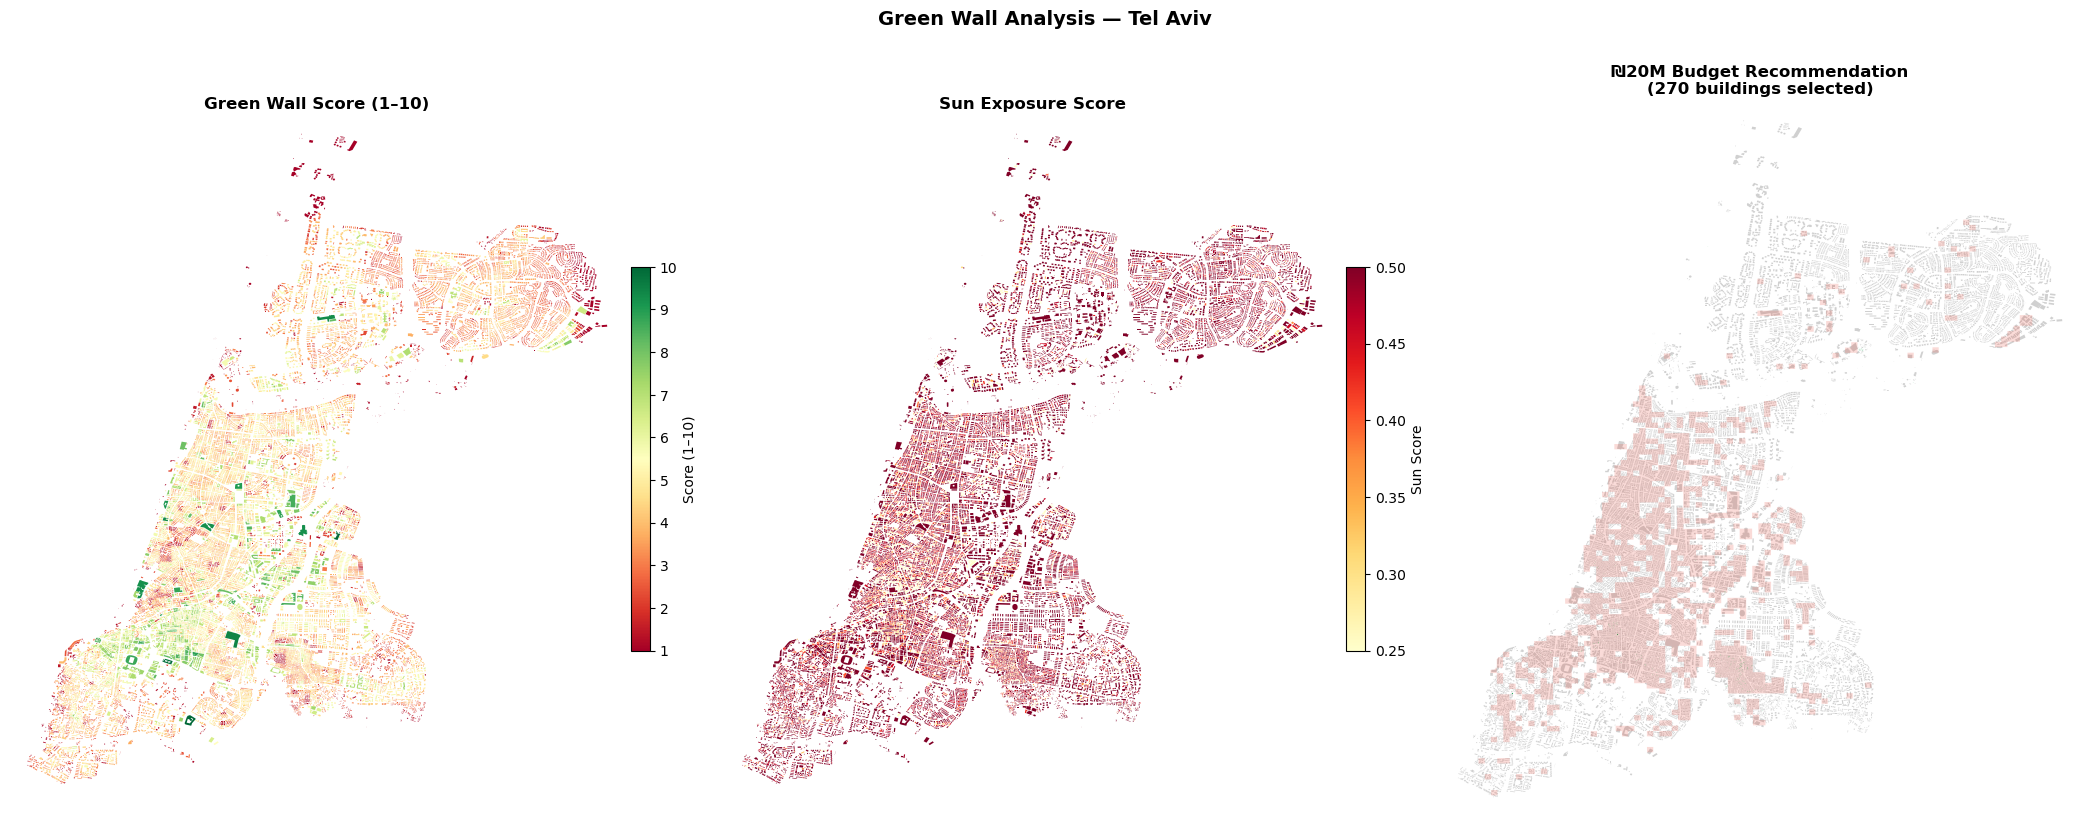

In [10]:
buildings_wgs = buildings.to_crs(4326)
grid_wgs      = grid.to_crs(4326)
border        = gpd.read_file('../Layers/tel_aviv_border.geojson')
minx, miny, maxx, maxy = buildings_wgs.total_bounds
pad = 0.003

fig, axes = plt.subplots(1, 3, figsize=(21, 9))

# --- Green wall score map ---
ax = axes[0]
buildings_wgs.plot(column='green_wall_score', cmap='RdYlGn',
                   legend=True, legend_kwds={'label':'Score (1–10)', 'shrink':0.6, 'fraction':0.03, 'pad':0.01},
                   linewidth=0, edgecolor='none', ax=ax)
border.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_xlim(minx - pad, maxx + pad); ax.set_ylim(miny - pad, maxy + pad)
ax.set_title('Green Wall Score (1–10)', fontweight='bold'); ax.axis('off')

# --- Sun score map ---
ax = axes[1]
buildings_wgs.plot(column='sun_score', cmap='YlOrRd',
                   legend=True, legend_kwds={'label':'Sun Score', 'shrink':0.6, 'fraction':0.03, 'pad':0.01},
                   linewidth=0, edgecolor='none', ax=ax)
border.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_xlim(minx - pad, maxx + pad); ax.set_ylim(miny - pad, maxy + pad)
ax.set_title('Sun Exposure Score', fontweight='bold'); ax.axis('off')

# --- Budget recommendation map (₪20M scenario) ---
ax = axes[2]
selected_ids = set(results[20_000_000])
buildings_wgs['selected_20m'] = buildings_wgs['id'].isin(selected_ids)
buildings_wgs[~buildings_wgs['selected_20m']].plot(ax=ax, color='#d0d0d0', linewidth=0, edgecolor='none')
buildings_wgs[ buildings_wgs['selected_20m']].plot(ax=ax, color='#27ae60', linewidth=0, edgecolor='none')
grid_wgs[grid_wgs['is_hotspot']==1].plot(ax=ax, color='#e74c3c', alpha=0.2, edgecolor='none')
border.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_xlim(minx - pad, maxx + pad); ax.set_ylim(miny - pad, maxy + pad)
ax.set_title(f'₪20M Budget Recommendation\n({len(results[20_000_000]):,} buildings selected)', fontweight='bold')
ax.axis('off')

plt.suptitle('Green Wall Analysis — Tel Aviv', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'green_wall_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

## 10 — Save

In [11]:
# Drop helper column before saving
out_cols = ['id','height','perimeter','footprint_area','eligible_wall_area',
            'cost_ils','sun_score','shade_penalty','heat_priority',
            'predicted_cooling','dist_to_hotspot','green_wall_score',
            'score_per_cost','geometry']
buildings[out_cols].to_file(OUT / 'tel_aviv_buildings_scored.gpkg', driver='GPKG')
print('Saved: outputs/tel_aviv_buildings_scored.gpkg')
print(f'Columns: {out_cols}')

Saved: outputs/tel_aviv_buildings_scored.gpkg
Columns: ['id', 'height', 'perimeter', 'footprint_area', 'eligible_wall_area', 'cost_ils', 'sun_score', 'shade_penalty', 'heat_priority', 'predicted_cooling', 'dist_to_hotspot', 'green_wall_score', 'score_per_cost', 'geometry']
